In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Import the arch package for GARCH modelling
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from scipy.stats import jarque_bera, anderson

import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

### Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True)  # set index to datetime
data.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


### Calculate Log Returns

In [3]:
# log returns are more appropriate for volatility modelling.
data['log_return'] = np.log(data['close']).diff()
data = data.dropna()

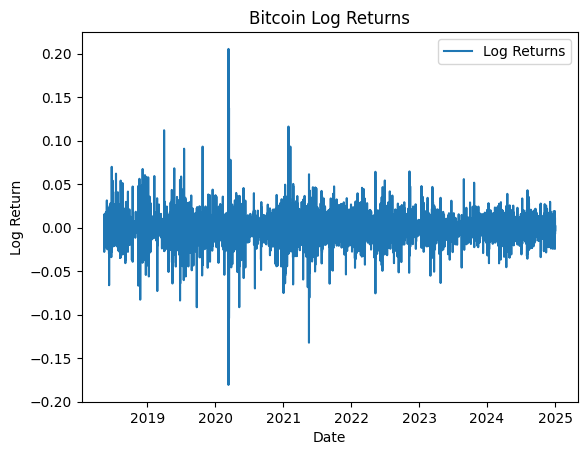

In [4]:
# Plot the log returns
plt.plot(data.index, data['log_return'], label='Log Returns')
plt.title('Bitcoin Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

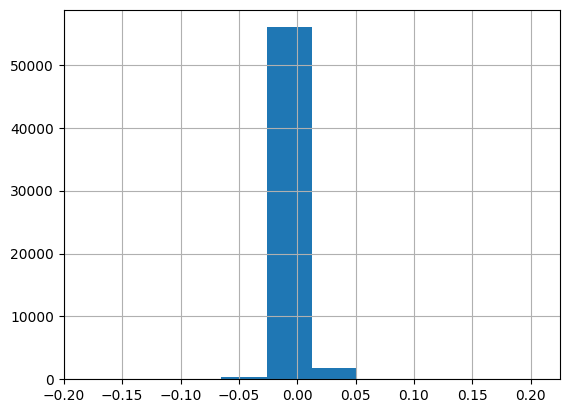

In [5]:
# Histogram 
data['log_return'].hist();

In [6]:
# Jarque-Bera Test and Anderson-Darling Test
jb_stat, jb_p = jarque_bera(data['log_return'].dropna())
print(f"Jarque-Bera Test: Statistic={jb_stat:.4f}, p-value={jb_p:.4f}")

result = anderson(data['log_return'].dropna(), dist='norm')
print(f"Anderson-Darling Test: Statistic={result.statistic:.4f}, Critical Values={result.critical_values}")

Jarque-Bera Test: Statistic=5095650.5305, p-value=0.0000
Anderson-Darling Test: Statistic=2358.3183, Critical Values=[0.576 0.656 0.787 0.918 1.092]


In [7]:
# Fit Different Distributions & Compare AIC/BIC
distributions = ['normal', 't', 'skewt', 'ged']
results = {}

for dist in distributions:
    model = arch_model(data['log_return'] * 100, mean='Constant', vol='GARCH', p=1, q=1, dist=dist)
    res = model.fit(disp="off")
    results[dist] = (res.aic, res.bic, res.loglikelihood)  # Use `.loglikelihood` instead of `.llf`

for dist, metrics in results.items():
    print(f"{dist.upper()} - AIC: {metrics[0]:.2f}, BIC: {metrics[1]:.2f}, Log-Likelihood: {metrics[2]:.2f}")

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


NORMAL - AIC: 105093.39, BIC: 105129.27, Log-Likelihood: -52542.69
T - AIC: 81499.56, BIC: 81544.41, Log-Likelihood: -40744.78
SKEWT - AIC: 81397.34, BIC: 81451.16, Log-Likelihood: -40692.67
GED - AIC: 83888.96, BIC: 83933.81, Log-Likelihood: -41939.48


### Check for ARCH Effects

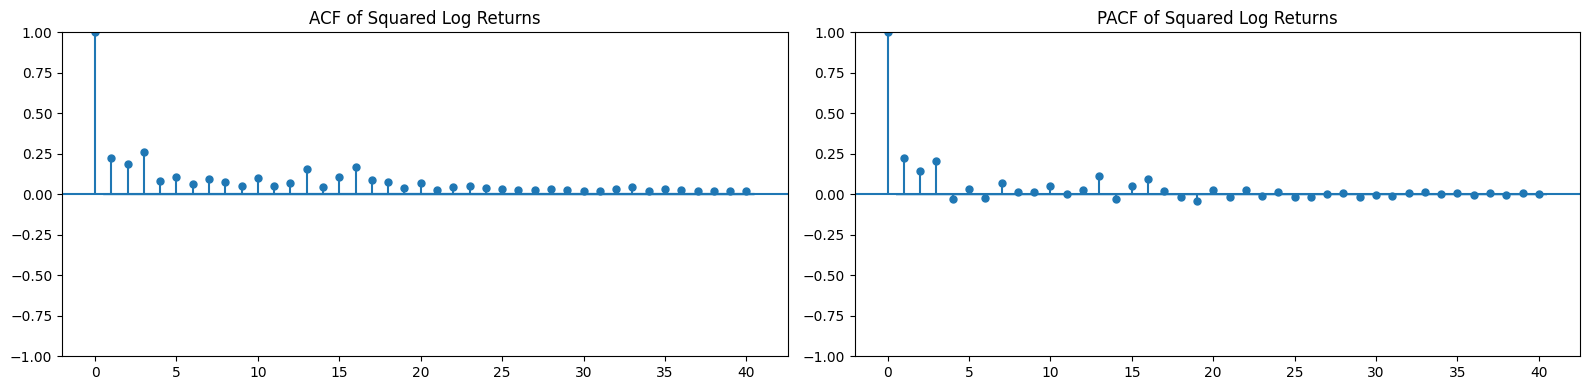

In [8]:
# Plot ACF and PACF of squared log returns as a proxy for volatility clustering.
squared_returns = data['log_return'] ** 2
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF of squared returns
plot_acf(squared_returns, lags=40, ax=axes[0])
axes[0].set_title('ACF of Squared Log Returns')

# PACF of squared returns
plot_pacf(squared_returns, lags=40, ax=axes[1])
axes[1].set_title('PACF of Squared Log Returns')

plt.tight_layout()
plt.show()

### Split Data into Train and Test Sets

In [9]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

### Fit a GARCH(1,1) Model on the Training Data

In [10]:
# Multiplying log returns by 100 scales them into percentages.
garch_model = arch_model(train['log_return'] * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='skewt')
garch_result = garch_model.fit(update_freq=5)
print(garch_result.summary())

Iteration:      5,   Func. Count:     47,   Neg. LLF: 71829.40891840636
Iteration:     10,   Func. Count:     96,   Neg. LLF: 47014.654778478536
Iteration:     15,   Func. Count:    144,   Neg. LLF: 1148698.6875605485
Iteration:     20,   Func. Count:    186,   Neg. LLF: 67883.25228909383
Iteration:     25,   Func. Count:    231,   Neg. LLF: 190317.58790551694
Iteration:     30,   Func. Count:    273,   Neg. LLF: 34324.74823634209
Iteration:     35,   Func. Count:    314,   Neg. LLF: 34184.26726333657
Iteration:     40,   Func. Count:    367,   Neg. LLF: 34321.399616465795
Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 34185.75634375314
            Iterations: 45
            Function evaluations: 376
            Gradient evaluations: 41
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:         

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


### Forecasting with the GARCH Model

In [11]:
# Define a fixed window length (adjust as needed)
window_length = 500

# This variable will store the last fitted parameters to use as a starting point.
last_params = None

forecasts = []
test_dates = []
rolling_train = train.copy()

for date, row in test.iterrows():
    # Use a fixed-size window: if our training set exceeds the window, take only the latest observations.
    if len(rolling_train) > window_length:
        training_window = rolling_train.iloc[-window_length:]
    else:
        training_window = rolling_train
    
    # Fit the GARCH model on the current window
    model = arch_model(training_window['log_return'] * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='skewt')
    
    # Use warm starting if we have previous parameter estimates
    if last_params is not None:
        res = model.fit(disp="off", starting_values=last_params)
    else:
        res = model.fit(disp="off")
    
    # Store the fitted parameters for the next iteration
    last_params = res.params.copy()
    
    # Forecast one day ahead
    forecast = res.forecast(horizon=1)
    variance_forecast = forecast.variance.values[-1, 0]
    volatility_forecast = np.sqrt(variance_forecast)
    
    forecasts.append(volatility_forecast)
    test_dates.append(date)
    
    # Append the current test observation to the rolling training set
    rolling_train = pd.concat([rolling_train, row.to_frame().T])

In [12]:
# Create a DataFrame for forecasted volatility
forecast_df = pd.DataFrame(data=forecasts, index=test_dates, columns=['Forecasted Volatility'])
forecast_df.head()

,Forecasted Volatility
2023-09-04 11:00:00,0.197971
2023-09-04 12:00:00,0.186535
2023-09-04 13:00:00,0.188013
2023-09-04 14:00:00,0.193969
2023-09-04 15:00:00,0.191957


### Compare Forecasted Volatility with a Realised Volatility Proxy

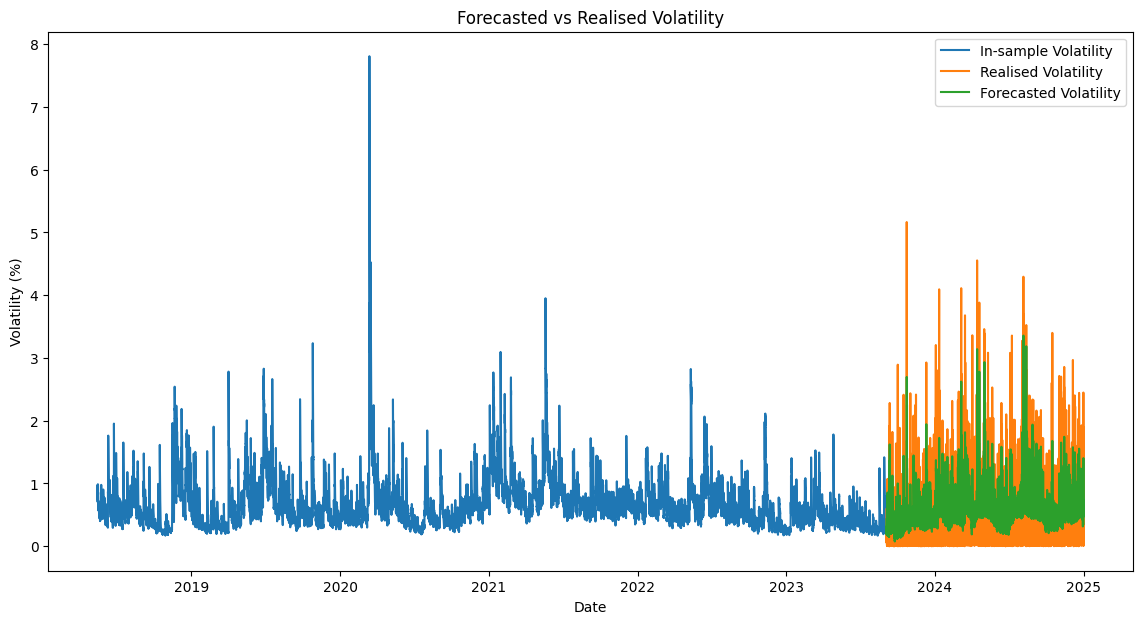

In [13]:
# In the absence of high-frequency data, we use the absolute log return as a proxy for realised volatility.
test['Realised Volatility'] = test['log_return'].abs() * 100

plt.figure(figsize=(14,7))
# In-sample volatility from the fitted GARCH model
plt.plot(train.index, garch_result.conditional_volatility, label='In-sample Volatility')
plt.plot(test.index, test['Realised Volatility'], label='Realised Volatility')
plt.plot(forecast_df.index, forecast_df['Forecasted Volatility'], label='Forecasted Volatility')
plt.title('Forecasted vs Realised Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

### Evaluate Model Performance

In [14]:
# Calculate the RMSE between the forecasted volatility and the realised volatility proxy.
common_index = forecast_df.index.intersection(test.index)
rmse = np.sqrt(mean_squared_error(test.loc[common_index, 'Realised Volatility'], forecast_df.loc[common_index, 'Forecasted Volatility']))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.4456
